In [5]:
# 删除损坏的文件
!rm -f rl_utils_BL.py
!pip install gymnasium
# 示例：假设文件在 GitHub 上的 raw 地址是 https://raw.githubusercontent.com/.../rl_utils_BL.py
#!wget https://raw.githubusercontent.com/HJZ-hub/SACIntelligentLayeredWaterInjection/blob/main/rl_utils_BL.py错误文件
!wget https://raw.githubusercontent.com/HJZ-hub/SACIntelligentLayeredWaterInjection/main/rl_utils_BL.py
#!wget https://github.com/HJZ-hub/SACIntelligentLayeredWaterInjection/blob/main/rl_utils_BL.py
import random
#import gym
# 将原来的 import gym 替换为：
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils_BL as rl_utils

--2026-04-22 08:49:40--  https://raw.githubusercontent.com/HJZ-hub/SACIntelligentLayeredWaterInjection/main/rl_utils_BL.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4441 (4.3K) [text/plain]
Saving to: ‘rl_utils_BL.py’

rl_utils_BL.py      100%[===================>]   4.34K  --.-KB/s    in 0s      

2026-04-22 08:49:40 (69.7 MB/s) - ‘rl_utils_BL.py’ saved [4441/4441]



In [6]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        # self.fc1 = nn.Sequential(
        #     nn.Linear(state_dim, hidden_dim),
        #     nn.LayerNorm(hidden_dim),
        #     nn.ReLU()
        # )
        self.fc_hidden1 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.fc_hidden2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.fc_hidden3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound  # action_bound是环境可以接受的动作最大值

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc_hidden1(x)
        x = self.fc_hidden2(x)
        x = self.fc_hidden3(x)
        return torch.tanh(self.fc2(x)) * self.action_bound


class QValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        # self.fc1 = nn.Sequential(
        #     nn.Linear(state_dim + action_dim, hidden_dim),
        #     nn.LayerNorm(hidden_dim),
        #     nn.ReLU()
        # )
        self.fc_hidden1 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.fc_hidden2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.fc_hidden3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        # self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1) # 拼接状态和动作
        x = F.relu(self.fc1(cat))
        x = self.fc_hidden1(x)
        x = self.fc_hidden2(x)
        x = self.fc_hidden3(x)
        # x = F.relu(self.fc2(x))
        return self.fc_out(x)

In [7]:



class DDPG:
    ''' DDPG算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.critic = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        self.target_actor = PolicyNet(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.target_critic = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        # 初始化目标价值网络并设置和价值网络相同的参数
        self.target_critic.load_state_dict(self.critic.state_dict())
        # 初始化目标策略网络并设置和策略相同的参数
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.sigma = sigma  # 高斯噪声的标准差,均值直接设为0
        self.tau = tau  # 目标网络软更新参数
        self.action_dim = action_dim
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        #action = self.actor(state).item()
        action = self.actor(state).detach().cpu().numpy()
        # 给动作添加噪声，增加探索
        action = action + self.sigma * np.random.randn(self.action_dim)
        # return action
        if len(action.shape) > 1 and action.shape[0] == 1:
            action = action.squeeze(0)
        return action


    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        next_q_values = self.target_critic(next_states, self.target_actor(next_states))
        q_targets = rewards + self.gamma * next_q_values * (1 - dones)
        critic_loss = torch.mean(F.mse_loss(self.critic(states, actions), q_targets))
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -torch.mean(self.critic(states, self.actor(states)))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        self.soft_update(self.actor, self.target_actor)  # 软更新策略网络
        self.soft_update(self.critic, self.target_critic)  # 软更新价值网络

In [9]:
# 1. 克隆项目
!git clone https://github.com/HJZ-hub/SACIntelligentLayeredWaterInjection.git

# 2. 进入目录
%cd SACIntelligentLayeredWaterInjection

# 3. 确保 env 是模块
!touch env/__init__.py

Cloning into 'SACIntelligentLayeredWaterInjection'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 141 (delta 19), reused 29 (delta 13), pack-reused 101 (from 1)
Receiving objects: 100% (141/141), 56.97 MiB | 26.70 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/SACIntelligentLayeredWaterInjection


In [12]:
import sys
sys.path.append('/content/SACIntelligentLayeredWaterInjection')
from env.water_env_ppo import FlowEnv as lenv
#from env.water_env_ppo import FlowEnv
actor_lr = 5e-4
critic_lr = 5e-4
num_episodes = 1000
hidden_dim = 128
gamma = 0.9
tau = 0.005  # 软更新参数
buffer_size = 10000
minimal_size = 1000
batch_size = 256
sigma = 0.1  # 高斯噪声标准差
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# env_name = 'Pendulum-v0'
# env = gym.make(env_name)

levelcount = 1
turn_max_time = 5
flow_erro = 0.02 #误差5%

env = lenv(levelcount = levelcount, turn_time=turn_max_time,flow_erro =flow_erro,adjust_max_count=200,meted='DDPG')
#env.render()
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值
agent = DDPG(state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device)
return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes, replay_buffer, minimal_size, batch_size)

/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(
Iteration 0:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Iteration 0:   0%|          | 0/100 [00:00<?, ?it/s]


TypeError: must be real number, not NoneType

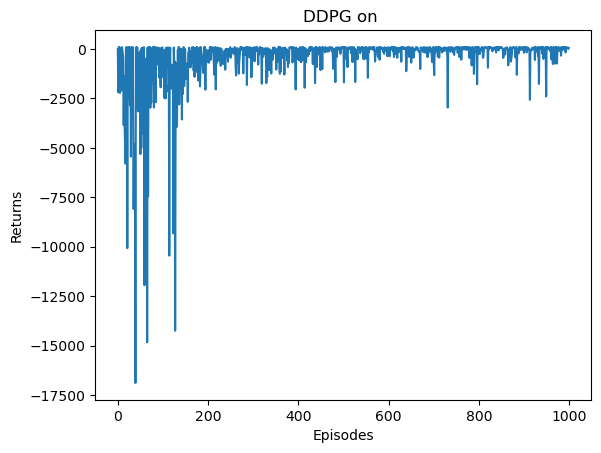

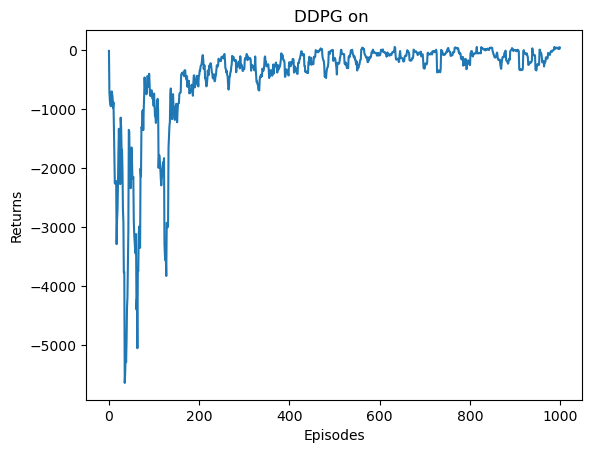

In [ ]:
import pandas as pd

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(''))
plt.show()

# 创建一个字典，将数据整理成适合构建DataFrame的数据结构
data = {
    "Episodes": episodes_list,
    "Returns": return_list
}

# 使用字典创建DataFrame对象
df = pd.DataFrame(data)
# 创建只有一列数据的DataFrame
df = pd.DataFrame({"Returns": return_list})

# 将DataFrame保存为Excel文件，指定文件名为output.xlsx
df.to_excel(f"{levelcount}_DDPG_reward.xlsx", index=False)

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(''))
plt.show()